# Belief-Aware LLMs — Single-Agent Evaluation Analysis
Visualizations of `eval_results.csv`. Only fully-completed (Runs=10) configurations are included.
All charts are deduped to the most recent run per unique `(Model, Domain, Prompt_Ver, Temp)` config.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)


def set_dynamic_ylim(ax=None, values=None, floor=0.0, pad_ratio=0.08):
    """Set a tight y-range from the values actually being plotted."""
    ax = ax or plt.gca()
    if values is None:
        values = [patch.get_height() for patch in ax.patches]
    values = [value for value in values if pd.notna(value)]
    if not values:
        return

    y_min = min(values)
    y_max = max(values)
    span = y_max - y_min
    if span == 0:
        span = max(abs(y_max), 1.0) * 0.05

    lower = max(floor, y_min - span * pad_ratio)
    upper = y_max + span * pad_ratio
    ax.set_ylim(lower, upper)


## Data Loading, Cleaning & Deduplication

In [ ]:
# ── Load New Metrics ──────────────────────────────────────────────────
# Create dataframes for calibration and evidence metrics

# CALIBRATION METRICS
metric_names = ['Average_Calibration_ECE', 'Average_Calibration_Brier', 'Average_Calibration_LogLoss']
dfs_calib = {}
for metric in metric_names:
    dfs_calib[metric] = df[df['Summary_Metric'] == metric].copy()
    for col in ['With_Store', 'Store_History', 'No_Store']:
        dfs_calib[metric][col] = pd.to_numeric(dfs_calib[metric][col], errors='coerce')

# EVIDENCE METRICS
evidence_metrics = ['Average_Evidence_Precision', 'Average_Evidence_Recall', 'Average_Evidence_F1', 
                    'Average_Evidence_Cited_Keys', 'Average_Evidence_Canonical_Keys']
dfs_evidence = {}
for metric in evidence_metrics:
    dfs_evidence[metric] = df[df['Summary_Metric'] == metric].copy()
    for col in ['With_Store', 'Store_History', 'No_Store']:
        dfs_evidence[metric][col] = pd.to_numeric(dfs_evidence[metric][col], errors='coerce')

print("✓ Calibration metrics loaded: ECE, Brier, LogLoss")
print("✓ Evidence metrics loaded: Precision, Recall, F1, Cited_Keys, Canonical_Keys")

In [ ]:
# ── Load ──────────────────────────────────────────────────────────────
df = pd.read_csv('eval_results.csv')

# Drop legacy entries with unknown metadata
df = df[df['Model'] != 'unknown']

# Ensure numeric Runs column and keep only fully-completed configs
df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce')
df = df[df['Runs'] == 10]

# ── Deduplicate ────────────────────────────────────────────────────────
# Multiple retry runs can exist for the same config. Keep only the most recent.
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = (
    df.sort_values('Timestamp', ascending=False)
      .drop_duplicates(subset=['Model', 'Domain', 'Prompt_Ver', 'Temp', 'Summary_Metric'], keep='first')
)

# ── Accuracy rows only ─────────────────────────────────────────────────
df_acc = df[df['Summary_Metric'] == 'Average_Accuracy'].copy()

# Clean accuracy value strings (handle typos like '0.79p')
for col in ['With_Store', 'Store_History', 'No_Store']:
    df_acc[col] = df_acc[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    df_acc[col] = pd.to_numeric(df_acc[col], errors='coerce')

# ── StoreGap ───────────────────────────────────────────────────────────
# How much does the Belief Store actually help? (With_Store - No_Store)
df_acc['StoreGap'] = df_acc['With_Store'] - df_acc['No_Store']

# ── Melt into long format ──────────────────────────────────────────────
id_vars = ['Timestamp', 'Domain', 'Model', 'Temp', 'Prompt_Ver', 'Runs', 'StoreGap']
value_vars = ['With_Store', 'Store_History', 'No_Store']

df_melted = pd.melt(
    df_acc, id_vars=id_vars, value_vars=value_vars,
    var_name='Context_Type', value_name='Accuracy'
)
df_melted = df_melted.dropna(subset=['Accuracy'])

# ── Feature extraction ─────────────────────────────────────────────────
def extract_base_domain(domain):
    for base in ['loan', 'alien_clinic', 'crime_scene', 'thorncrester']:
        if domain.startswith(base):
            return base
    return 'other'

def extract_scenario(domain):
    for scenario in ['_belief_maintenance', '_negation', '_absurd_temporal', '_grounding']:
        if domain.endswith(scenario):
            return scenario.lstrip('_')
    return 'base'

df_melted['Base_Domain'] = df_melted['Domain'].apply(extract_base_domain)
df_melted['Scenario']    = df_melted['Domain'].apply(extract_scenario)

# Also add to df_acc so StoreGap chart has access to these columns
df_acc['Base_Domain'] = df_acc['Domain'].apply(extract_base_domain)
df_acc['Scenario']    = df_acc['Domain'].apply(extract_scenario)

print(f"Total rows after cleaning: {len(df_melted)}")
print(f"Models: {sorted(df_melted['Model'].unique())}")
print(f"Prompts: {sorted(df_melted['Prompt_Ver'].unique())}")
print(f"Temperatures: {sorted(df_melted['Temp'].unique())}")


In [ ]:
# ── Belief Maintenance results on 2026-05-08 ─────────────────────────
target_date = pd.to_datetime("2026-05-08").date()
bm = df_acc[
    (df_acc['Domain'].str.contains('belief_maintenance', na=False))
    & (df_acc['Timestamp'].dt.date == target_date)
].copy()

print(f"Rows for belief_maintenance on {target_date}: {len(bm)}")
display(bm.sort_values(['Domain', 'Model', 'Prompt_Ver', 'Temp']))


In [ ]:
# ── Calibration Metrics Summary ───────────────────────────────────────
print("=" * 80)
print("CALIBRATION METRICS SUMMARY (lower is better)")
print("=" * 80)
for metric in ['Average_Calibration_ECE', 'Average_Calibration_Brier', 'Average_Calibration_LogLoss']:
    if len(dfs_calib[metric]) > 0:
        print(f"\n{metric}:")
        summary = dfs_calib[metric][['Domain', 'Model', 'Prompt_Ver', 'With_Store', 'Store_History', 'No_Store']].copy()
        summary = summary.dropna(subset=['With_Store', 'Store_History', 'No_Store'], how='all')
        display(summary.head(10))
    else:
        print(f"{metric}: No data")

print("\n" + "=" * 80)
print("EVIDENCE METRICS SUMMARY (F1, Precision, Recall)")
print("=" * 80)
for metric in evidence_metrics[:3]:  # Precision, Recall, F1
    if len(dfs_evidence[metric]) > 0:
        print(f"\n{metric}:")
        summary = dfs_evidence[metric][['Domain', 'Model', 'Prompt_Ver', 'With_Store', 'Store_History', 'No_Store']].copy()
        summary = summary.dropna(subset=['With_Store', 'Store_History', 'No_Store'], how='all')
        display(summary.head(10))
    else:
        print(f"{metric}: No data")

print("\n" + "=" * 80)
print("EVIDENCE KEY COUNTS (citation tracking)")
print("=" * 80)
for metric in evidence_metrics[3:]:  # Cited_Keys, Canonical_Keys
    if len(dfs_evidence[metric]) > 0:
        print(f"\n{metric}:")
        summary = dfs_evidence[metric][['Domain', 'Model', 'Prompt_Ver', 'With_Store', 'Store_History', 'No_Store']].copy()
        summary = summary.dropna(subset=['With_Store', 'Store_History', 'No_Store'], how='all')
        display(summary.head(10))
    else:
        print(f"{metric}: No data")

## Data Coverage Summary
Verify how many unique configs are in the dataset before plotting.

In [ ]:
# ── Metrics Comparison Heatmaps ────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# Create a combined metrics DataFrame for heatmap visualization
metrics_to_viz = {
    'Accuracy': 'Average_Accuracy',
    'ECE': 'Average_Calibration_ECE',
    'Brier': 'Average_Calibration_Brier',
    'LogLoss': 'Average_Calibration_LogLoss',
    'Evidence_F1': 'Average_Evidence_F1',
    'Evidence_Precision': 'Average_Evidence_Precision',
    'Evidence_Recall': 'Average_Evidence_Recall'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('New Evaluation Metrics: Calibration & Evidence Quality', fontsize=16, fontweight='bold')

# Helper function to create metric heatmap
def create_metric_heatmap(ax, metric_df, title, cmap='RdYlGn', vmin=None, vmax=None):
    if len(metric_df) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        ax.set_title(title)
        return
    
    # Pivot: rows=Domain, cols=Model, values=With_Store
    pivot = metric_df.pivot_table(
        index='Domain', columns='Model', values='With_Store', aggfunc='mean'
    )
    
    if pivot.empty:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        ax.set_title(title)
        return
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax, cbar_kws={'label': title},
                vmin=vmin, vmax=vmax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel('Domain')

# ECE (Expected Calibration Error - lower is better)
create_metric_heatmap(axes[0, 0], dfs_calib['Average_Calibration_ECE'], 
                      'ECE (Lower = Better)', cmap='RdYlGn_r', vmin=0, vmax=1)

# Brier (lower is better)
create_metric_heatmap(axes[0, 1], dfs_calib['Average_Calibration_Brier'],
                      'Brier Score (Lower = Better)', cmap='RdYlGn_r', vmin=0, vmax=1)

# Evidence F1 (higher is better)
create_metric_heatmap(axes[1, 0], dfs_evidence['Average_Evidence_F1'],
                      'Evidence F1 Score (Higher = Better)', cmap='RdYlGn', vmin=0, vmax=1)

# Evidence Precision (higher is better)
create_metric_heatmap(axes[1, 1], dfs_evidence['Average_Evidence_Precision'],
                      'Evidence Precision (Higher = Better)', cmap='RdYlGn', vmin=0, vmax=1)

plt.tight_layout()
plt.show()

print("\nHeatmaps show avg metric values across domain/model combinations with With_Store context")

In [ ]:
# ── Context Impact Analysis ────────────────────────────────────────────
print("\n" + "=" * 80)
print("BELIEF STORE IMPACT ON METRICS (With_Store vs No_Store)")
print("=" * 80)

for metric_name in ['Average_Calibration_ECE', 'Average_Evidence_F1']:
    if metric_name in dfs_calib:
        df_m = dfs_calib[metric_name]
    else:
        df_m = dfs_evidence[metric_name]
    
    if len(df_m) == 0:
        continue
    
    # Compare With_Store vs No_Store
    comparison = df_m[['Domain', 'Model', 'With_Store', 'No_Store']].copy()
    comparison = comparison.dropna(subset=['With_Store', 'No_Store'])
    
    if len(comparison) > 0:
        comparison['Improvement'] = comparison['No_Store'] - comparison['With_Store']
        # For F1, positive is better; for ECE, negative (lower) is better
        is_lower_better = 'ECE' in metric_name or 'Brier' in metric_name or 'LogLoss' in metric_name
        if is_lower_better:
            comparison['Improvement_Pct'] = (comparison['Improvement'] / comparison['No_Store'].abs() * 100).round(1)
            improvement_label = "% Better (lower)"
        else:
            comparison['Improvement_Pct'] = (comparison['Improvement'] / comparison['No_Store'].abs() * 100).round(1)
            improvement_label = "% Better (higher)"
        
        print(f"\n{metric_name}:")
        print(comparison[['Domain', 'Model', 'With_Store', 'No_Store', 'Improvement_Pct']].to_string())


In [ ]:
# ── Data Coverage Summary ─────────────────────────────────────────────
summary = (
    df_acc.groupby(['Model', 'Domain', 'Prompt_Ver', 'Temp'])
    .size()
    .reset_index(name='Row_Count')
)
print(f"Unique (Model × Domain × Prompt × Temp) configs: {len(summary)}")
summary.sort_values(['Model', 'Domain']).head(30)



## Chart 1 — Overall Context Condition Impact

In [ ]:
# ── Chart 1: Overall Context Condition Impact ─────────────────────────
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Context_Type', y='Accuracy',
            order=['With_Store', 'Store_History', 'No_Store'])
plt.title('Overall Average Accuracy by Context Type', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Context Condition')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## Chart 2 — Model × Context Breakdown

In [ ]:
# ── Chart 2: Model × Context ──────────────────────────────────────────
plt.figure(figsize=(14, 7))
sns.barplot(data=df_melted, x='Model', y='Accuracy', hue='Context_Type',
            hue_order=['With_Store', 'Store_History', 'No_Store'])
plt.title('Model Performance Across Context Types', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Context')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## Chart 3 — Prompt Version Impact
*(With_Store only — isolates prompt quality from context effects)*

In [ ]:
# ── Chart 3: Prompt Version Impact (With_Store only) ──────────────────
df_ws = df_melted[df_melted['Context_Type'] == 'With_Store']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_ws, x='Prompt_Ver', y='Accuracy', hue='Model',
            order=sorted(df_ws['Prompt_Ver'].unique()))
plt.title('Prompt Version Impact by Model (With Store)', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Prompt Version')
plt.legend(title='Model')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## Chart 4 — Temperature Impact
*(With_Store only — compares deterministic vs stochastic runs)*

In [ ]:
# ── Chart 4: Temperature Impact (With_Store, per model) ───────────────
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ws, x='Model', y='Accuracy', hue='Temp',
            palette='muted')
plt.title('Temperature Impact on Accuracy (With Store)', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Temperature')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## Chart 5 — Base Domain × Context

In [ ]:
# ── Chart 5: Base Domain × Context ───────────────────────────────────
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Base_Domain', y='Accuracy', hue='Context_Type',
            hue_order=['With_Store', 'Store_History', 'No_Store'])
plt.title('Performance by Base Domain', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Base Domain')
plt.legend(title='Context')
set_dynamic_ylim()
plt.tight_layout()
plt.show()

# Diagnostic: highest average accuracy shown in Chart 5
group = df_melted.groupby(['Base_Domain', 'Context_Type'])['Accuracy'].mean().reset_index()
max_row = group.loc[group['Accuracy'].idxmax()]
print("Highest mean accuracy (Base_Domain × Context_Type):")
print(max_row.to_dict())
print('\nTop 10 groups by mean Accuracy:')
display(group.sort_values('Accuracy', ascending=False).head(10))
print('\nOverall maximum individual Accuracy value in df_melted:')
print(df_melted['Accuracy'].max())


## Chart 6 — Scenario Type × Context

In [ ]:
# ── Chart 6: Scenario Type × Context ─────────────────────────────────
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Scenario', y='Accuracy', hue='Context_Type',
            hue_order=['With_Store', 'Store_History', 'No_Store'])
plt.title('Performance by Scenario Type', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Scenario Type')
plt.legend(title='Context')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## Chart 7 — Per-Model × Base Domain (With Store)

In [ ]:
# ── Chart 7: Per-Model × Base Domain (With_Store only) ────────────────
plt.figure(figsize=(14, 7))
sns.barplot(data=df_ws, x='Base_Domain', y='Accuracy', hue='Model')
plt.title('Per-Model Performance Across Base Domains (With Store)', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Base Domain')
plt.legend(title='Model')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## Chart 8 — Per-Model × Scenario Type (With Store)

In [ ]:
# ── Chart 8: Per-Model × Scenario Type (With_Store only) ─────────────
plt.figure(figsize=(14, 7))
sns.barplot(data=df_ws, x='Scenario', y='Accuracy', hue='Model')
plt.title('Per-Model Performance Across Scenario Types (With Store)', fontsize=16)
plt.ylabel('Average Accuracy')
plt.xlabel('Scenario Type')
plt.legend(title='Model')
set_dynamic_ylim()
plt.tight_layout()
plt.show()


## Chart 9 — StoreGap: How Much Does the Belief Store Help?
`StoreGap = With_Store − No_Store`. A positive bar means the belief store is helping. A zero or negative bar is a red flag.

In [ ]:
# ── Chart 9: StoreGap — How much does the Belief Store help? ──────────
# StoreGap = With_Store accuracy - No_Store accuracy (per config, not melted)
df_gap = df_acc[['Model', 'Domain', 'Prompt_Ver', 'Temp', 'Base_Domain', 'Scenario', 'StoreGap']].copy()
df_gap = df_gap.dropna(subset=['StoreGap'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# By Model
sns.barplot(data=df_gap, x='Model', y='StoreGap', ax=axes[0], palette='rocket')
axes[0].set_title('Belief Store Benefit by Model', fontsize=14)
axes[0].set_ylabel('With_Store − No_Store Accuracy')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=30)

# By Scenario
sns.barplot(data=df_gap, x='Scenario', y='StoreGap', ax=axes[1], palette='rocket')
axes[1].set_title('Belief Store Benefit by Scenario Type', fontsize=14)
axes[1].set_ylabel('With_Store − No_Store Accuracy')
axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('StoreGap: Benefit of the Belief Store', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Variance Summary
Variance values come from the `Variance_Raw_Score` rows in `eval_results.csv` (variance of raw per-run scores).
This notebook does not have per-run rows, so it cannot recompute variance directly from accuracy; it can only aggregate the recorded variance.

In [ ]:
# ── Variance Summary (Replacing Error Bars) ───────────────────────────
# Instead of error bars on the charts, here is the raw numerical variance across runs.
# We pull the 'Variance_Raw_Score' rows and display the average variance.

df_var = df[df['Summary_Metric'] == 'Variance_Raw_Score'].copy()

for col in ['With_Store', 'Store_History', 'No_Store']:
    df_var[col] = df_var[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    df_var[col] = pd.to_numeric(df_var[col], errors='coerce')

df_var['Avg_Variance'] = df_var[['With_Store', 'Store_History', 'No_Store']].mean(axis=1)
df_var['Base_Domain'] = df_var['Domain'].apply(extract_base_domain)

variance_summary = df_var.groupby(['Model', 'Base_Domain'])['Avg_Variance'].mean().reset_index()
variance_summary = variance_summary.pivot(index='Model', columns='Base_Domain', values='Avg_Variance').round(4)

print("Average Variance Score across all 10 runs (0.0 = perfect consistency)")
display(variance_summary)


In [ ]:
# ## Variance Analysis per Evaluation Scenario
# Uses Variance_Raw_Score rows, not accuracy rows.

df_var_long = df_var.melt(
    id_vars=['Model', 'Domain', 'Prompt_Ver', 'Temp'],
    value_vars=['With_Store', 'Store_History', 'No_Store'],
    var_name='Context_Type',
    value_name='Variance',
)
df_var_long['Scenario'] = df_var_long['Domain'].apply(extract_scenario)
df_var_long = df_var_long.dropna(subset=['Variance'])

scenario_variance = df_var_long.groupby(['Scenario', 'Context_Type'])['Variance'].mean().round(4)
variance_table = scenario_variance.unstack(level='Context_Type')

print("Average Variance (from Variance_Raw_Score) per Scenario and Context:")
display(variance_table)

overall_scenario_var = (
    df_var_long.groupby('Scenario')['Variance']
    .mean()
    .round(4)
    .to_frame('Avg_Variance')
)

print("\nAverage Variance per Scenario (all contexts):")
display(overall_scenario_var)


#VARIANCE PER DOMAIN

## Sanity Checks
Quick validations for variance consistency and scenario coverage.

In [ ]:
# ── Variance vs StdDev consistency ───────────────────────────────────
df_std = df[df['Summary_Metric'] == 'StdDev_Raw_Score'].copy()

for col in ['With_Store', 'Store_History', 'No_Store']:
    df_std[col] = df_std[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    df_std[col] = pd.to_numeric(df_std[col], errors='coerce')

key_cols = ['Model', 'Domain', 'Prompt_Ver', 'Temp', 'Runs']
df_var_keyed = df_var[key_cols + ['With_Store', 'Store_History', 'No_Store']].copy()
df_std_keyed = df_std[key_cols + ['With_Store', 'Store_History', 'No_Store']].copy()

merged = df_var_keyed.merge(df_std_keyed, on=key_cols, suffixes=('_var', '_std'), how='inner')

for ctx in ['With_Store', 'Store_History', 'No_Store']:
    merged[f'{ctx}_std_sq'] = merged[f'{ctx}_std'] ** 2
    merged[f'{ctx}_abs_diff'] = (merged[f'{ctx}_var'] - merged[f'{ctx}_std_sq']).abs()

tolerance = 1e-4
diff_cols = [f'{ctx}_abs_diff' for ctx in ['With_Store', 'Store_History', 'No_Store']]
merged['Max_Abs_Diff'] = merged[diff_cols].max(axis=1)

flagged = merged[merged['Max_Abs_Diff'] > tolerance]
print(f"Variance vs StdDev^2 check: {len(flagged)} rows exceed tolerance {tolerance}")
display(flagged[key_cols + ['Max_Abs_Diff']].head(20))

# ── Scenario coverage / unknown suffixes ─────────────────────────────
known_suffixes = [
    '_belief_maintenance', '_negation', '_absurd_temporal', '_grounding',
    '_hard', '_extended', '_belief_awareness', '_absurd', '_trace_selection', '_1hop', '_2hop', '_3hop', '_4hop'
 ]

def detect_suffix(domain):
    for suffix in sorted(known_suffixes, key=len, reverse=True):
        if domain.endswith(suffix):
            return suffix.lstrip('_')
    return 'base'

df_acc['Detected_Suffix'] = df_acc['Domain'].apply(detect_suffix)
coverage = df_acc.groupby(['Detected_Suffix', 'Base_Domain']).size().reset_index(name='Count')
print("Scenario coverage by suffix and base domain:")
display(coverage.sort_values(['Detected_Suffix', 'Base_Domain']))

unknown = df_acc[(df_acc['Detected_Suffix'] == 'base') & (df_acc['Domain'].str.contains('_'))]
print("\nDomains with suffixes not in the known list:")
display(unknown[['Domain']].drop_duplicates().sort_values('Domain').head(50))


## Additional Analysis
Model-level summaries, consistency checks, and missing-evaluation detection against the registry.

In [153]:
# ── Model-level summary stats ─────────────────────────────────────────
model_summary = (
    df_acc.groupby('Model')[['With_Store', 'Store_History', 'No_Store', 'StoreGap']]
    .agg(['mean', 'median', 'min', 'max'])
    .round(4)
 )
print("Model-level summary (Accuracy + StoreGap):")
display(model_summary)

# ── Best/Worst configs by StoreGap ────────────────────────────────────
gap_rank = df_acc.sort_values('StoreGap', ascending=False)
print("Top 10 StoreGap configs (belief store helps most):")
display(gap_rank[['Model', 'Domain', 'Prompt_Ver', 'Temp', 'With_Store', 'No_Store', 'StoreGap']].head(10))

print("Bottom 10 StoreGap configs (belief store helps least):")
display(gap_rank[['Model', 'Domain', 'Prompt_Ver', 'Temp', 'With_Store', 'No_Store', 'StoreGap']].tail(10))

# ── Variance vs Accuracy correlation ─────────────────────────────────
df_var_mean = df_var.copy()
df_var_mean['Avg_Variance'] = df_var_mean[['With_Store', 'Store_History', 'No_Store']].mean(axis=1)
df_acc_mean = df_acc.copy()
df_acc_mean['Avg_Accuracy'] = df_acc_mean[['With_Store', 'Store_History', 'No_Store']].mean(axis=1)

var_acc = df_var_mean.merge(
    df_acc_mean[['Model', 'Domain', 'Prompt_Ver', 'Temp', 'Avg_Accuracy']],
    on=['Model', 'Domain', 'Prompt_Ver', 'Temp'],
    how='inner'
)
corr = var_acc['Avg_Variance'].corr(var_acc['Avg_Accuracy'])
print(f"Correlation between Avg_Variance and Avg_Accuracy: {corr:.4f}")

# ── Missing evaluations (compare to registry) ─────────────────────────
try:
    from evaluation.run_evals import DOMAIN_REGISTRY
    expected_domains = sorted(DOMAIN_REGISTRY.keys())
    observed_domains = sorted(df_acc['Domain'].unique())
    missing = sorted(set(expected_domains) - set(observed_domains))
    extra = sorted(set(observed_domains) - set(expected_domains))

    print(f"Expected domains from registry: {len(expected_domains)}")
    print(f"Observed domains in CSV: {len(observed_domains)}")
    print(f"Missing domains (in registry but not in CSV): {len(missing)}")
    display(pd.DataFrame(missing, columns=['Missing_Domain']).head(50))

    if extra:
        print(f"Extra domains (in CSV but not in registry): {len(extra)}")
        display(pd.DataFrame(extra, columns=['Extra_Domain']).head(50))
except Exception as e:
    print("Could not import DOMAIN_REGISTRY for missing-eval check:", e)


Model-level summary (Accuracy + StoreGap):


With_Store                    Store_History                No_Store  \
                mean median   min   max          mean median min max     mean   
Model                                                                           
gemma3:1b        0.8    0.8  0.77  0.83           NaN    NaN NaN NaN    0.085   

                             StoreGap                     
          median   min   max     mean median   min   max  
Model                                                     
gemma3:1b   0.08  0.01  0.17    0.715  0.705  0.66  0.79

Top 10 StoreGap configs (belief store helps most):


,Model,Domain,Prompt_Ver,Temp,With_Store,No_Store,StoreGap
249,gemma3:1b,thorncrester_belief_maintenance,v15,0.7,0.80,0.01,0.79
238,gemma3:1b,alien_clinic_belief_maintenance,v15,0.7,0.80,0.07,0.73
227,gemma3:1b,loan_belief_maintenance,v15,0.7,0.77,0.09,0.68
260,gemma3:1b,crime_scene_belief_maintenance,v15,0.7,0.83,0.17,0.66


Bottom 10 StoreGap configs (belief store helps least):


,Model,Domain,Prompt_Ver,Temp,With_Store,No_Store,StoreGap
249,gemma3:1b,thorncrester_belief_maintenance,v15,0.7,0.80,0.01,0.79
238,gemma3:1b,alien_clinic_belief_maintenance,v15,0.7,0.80,0.07,0.73
227,gemma3:1b,loan_belief_maintenance,v15,0.7,0.77,0.09,0.68
260,gemma3:1b,crime_scene_belief_maintenance,v15,0.7,0.83,0.17,0.66


Correlation between Avg_Variance and Avg_Accuracy: 0.4384
Expected domains from registry: 54
Observed domains in CSV: 4
Missing domains (in registry but not in CSV): 50


,Missing_Domain
0,alien_clinic
1,alien_clinic_1hop
2,alien_clinic_2hop
3,alien_clinic_3hop
4,alien_clinic_4hop
5,alien_clinic_absurd
6,alien_clinic_absurd_temporal
7,alien_clinic_belief_awareness
8,alien_clinic_cf
9,alien_clinic_extended


## New Graphs
Additional visualizations to highlight model/domain patterns and stability.

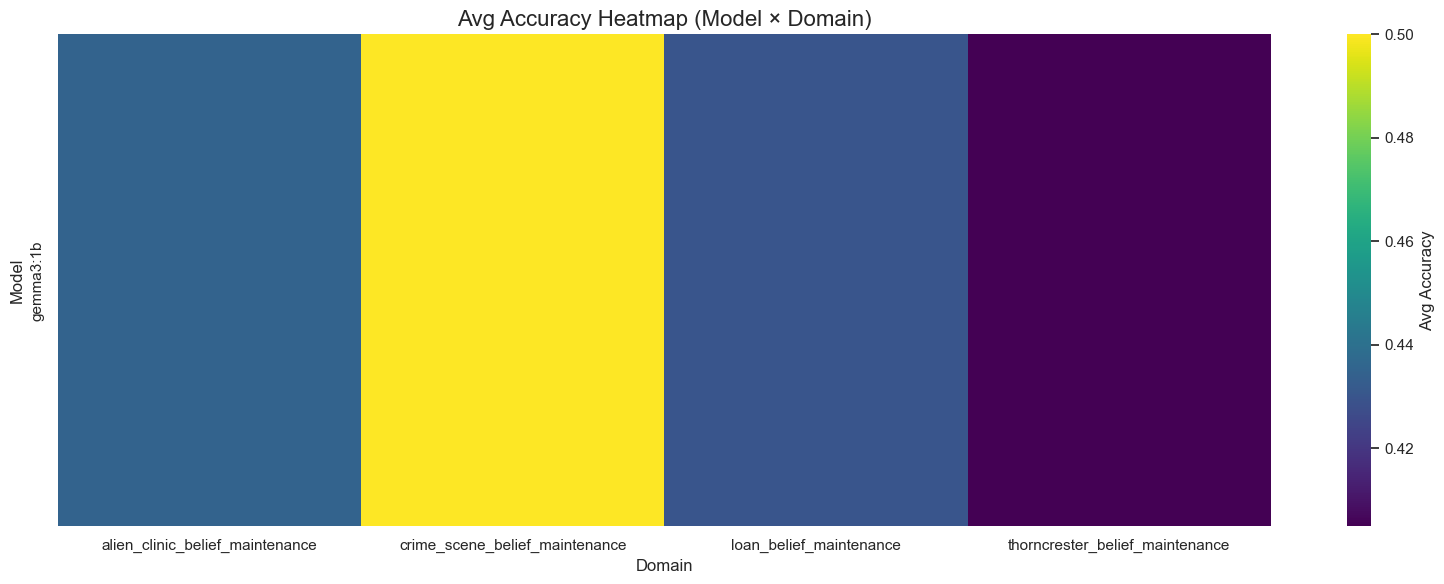

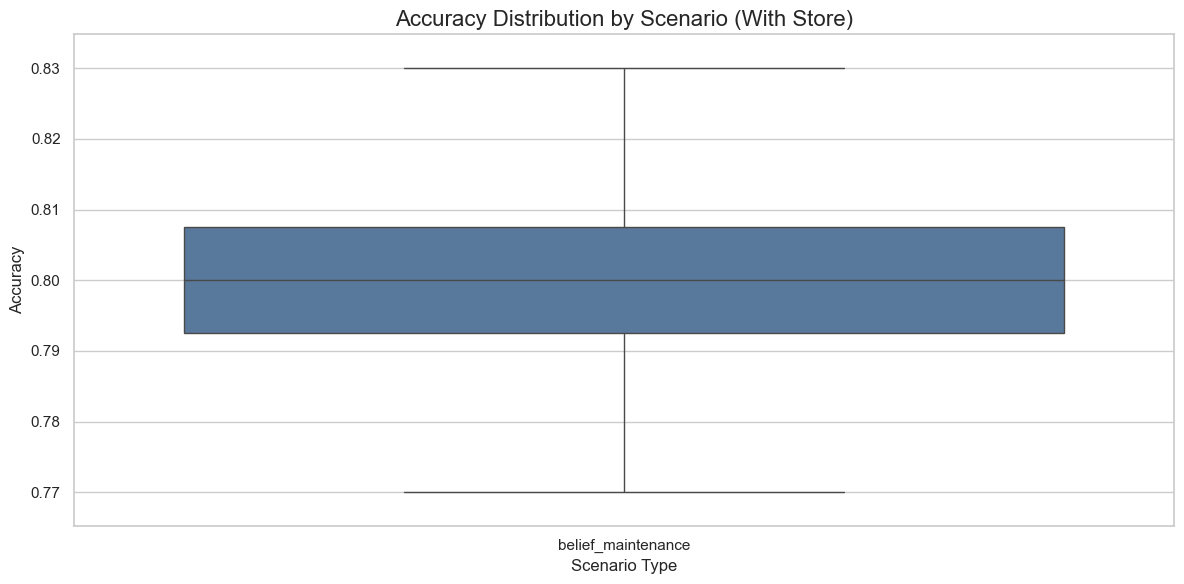

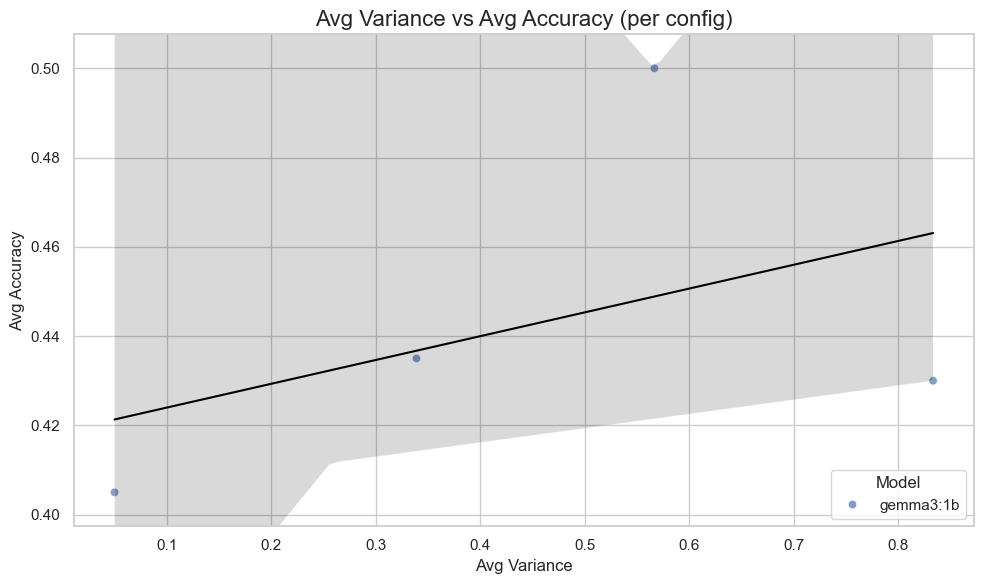

No rows for model 'qwen' found in df_acc.


In [152]:
# ── Graph 10: Heatmap of Avg Accuracy (Model × Domain) ────────────────
heat = (
    df_acc.assign(Avg_Accuracy=df_acc[['With_Store', 'Store_History', 'No_Store']].mean(axis=1))
    .groupby(['Model', 'Domain'])['Avg_Accuracy']
    .mean()
    .reset_index()
    .pivot(index='Model', columns='Domain', values='Avg_Accuracy')
 )
plt.figure(figsize=(16, 6))
vmax = heat.max().max()
vmin = heat.min().min()
sns.heatmap(heat, cmap='viridis', vmin=vmin, vmax=vmax, annot=False, cbar_kws={'label': 'Avg Accuracy'})
plt.title('Avg Accuracy Heatmap (Model × Domain)', fontsize=16)
plt.ylabel('Model')
plt.xlabel('Domain')
plt.tight_layout()
plt.show()

# ── Graph 11: Accuracy Distribution by Scenario (With_Store) ──────────
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_ws, x='Scenario', y='Accuracy', color='#4C78A8')
plt.title('Accuracy Distribution by Scenario (With Store)', fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Scenario Type')
set_dynamic_ylim(values=df_ws['Accuracy'])
plt.tight_layout()
plt.show()

# ── Graph 12: Variance vs Accuracy Scatter ────────────────────────────
var_acc_plot = var_acc.copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=var_acc_plot, x='Avg_Variance', y='Avg_Accuracy', hue='Model', alpha=0.7)
sns.regplot(data=var_acc_plot, x='Avg_Variance', y='Avg_Accuracy', scatter=False, color='black', line_kws={'linewidth': 1.5})
plt.title('Avg Variance vs Avg Accuracy (per config)', fontsize=16)
plt.xlabel('Avg Variance')
plt.ylabel('Avg Accuracy')
set_dynamic_ylim(values=var_acc_plot['Avg_Accuracy'])
plt.tight_layout()
plt.show()

# ── Diagnostic: Qwen StoreGap analysis ───────────────────────────────
qwen_df = df_acc[df_acc['Model'].astype(str).str.contains('qwen', case=False, na=False)].copy()
if qwen_df.empty:
    print("No rows for model 'qwen' found in df_acc.")
else:
    qwen_df = qwen_df.dropna(subset=['StoreGap'])
    print("Qwen StoreGap summary:")
    print(qwen_df['StoreGap'].describe())

    worst = qwen_df.sort_values('StoreGap').head(10)
    print('\nTop 10 most negative StoreGap (With_Store - No_Store) for Qwen:')
    display(worst[['Model', 'Domain', 'Prompt_Ver', 'Temp', 'With_Store', 'No_Store', 'StoreGap']])

    plt.figure(figsize=(8, 4))
    sns.barplot(data=worst, x='StoreGap', y='Domain', palette='rocket')
    plt.title('Top 10 most negative StoreGap for Qwen')
    plt.xlabel('With_Store − No_Store')
    plt.tight_layout()
    plt.show()
